# Clair Wage Advance — Default Risk Model

**Objective:** Predict whether a user will default on a wage advance, and propose a business rule for accept/reject decisions.

**Approach:** Logistic Regression baseline → LightGBM main model, evaluated via ROC AUC and Precision-Recall AUC (more informative under class imbalance). Business threshold selected by a cost-weighted analysis.

**Bonus:** A simple, interpretable formula for estimating a safe advance amount per user.

---

## 0. Setup

In [ ]:
# Standard library
import os
import warnings
warnings.filterwarnings('ignore')

# Load environment variables from .env if present
from dotenv import load_dotenv
load_dotenv()

# Data
import numpy as np
import pandas as pd
from sqlalchemy import create_engine, text

# Viz
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Modeling
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
import lightgbm as lgb

# Plotting defaults
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
TARGET = 'DEFAULT_FLAG'

# Database credentials loaded from environment variables (see risk_model/.env)
DB_CONFIG = {
    'host'  : os.environ['DB_HOST'],
    'port'  : int(os.environ['DB_PORT']),
    'dbname': os.environ['DB_NAME'],
    'user'  : os.environ['DB_USER'],
    'password': os.environ['DB_PASSWORD'],
}

print('Setup complete.')


## 1. Data Ingestion

In [2]:
def build_connection_string(cfg: dict) -> str:
    """Construct a SQLAlchemy PostgreSQL URI from a config dict."""
    return (
        f"postgresql+psycopg2://{cfg['user']}:{cfg['password']}"
        f"@{cfg['host']}:{cfg['port']}/{cfg['dbname']}"
        "?sslmode=require"
    )


def load_data(cfg: dict, table: str = 'loan_characteristics') -> pd.DataFrame:
    """
    Connect to the Aiven PostgreSQL instance and load the full table.
    Returns a DataFrame with all columns lowercased for convenience.
    SQLAlchemy 2.x requires raw SQL strings to be wrapped in text().
    """
    engine = create_engine(build_connection_string(cfg))
    with engine.connect() as conn:
        df = pd.read_sql(text(f'SELECT * FROM {table}'), conn)
    df.columns = df.columns.str.lower()
    print(f'Loaded {len(df):,} rows × {df.shape[1]} columns from `{table}`.')
    return df


df_raw = load_data(DB_CONFIG)
df_raw.head(3)

Loaded 119,609 rows × 24 columns from `loan_characteristics`.


,user_id,business_id,started_onboarding_at,hire_date,loan_creation_dt,due_date,date_of_last_paycheck,loan_amount,unique_pay_periods,on_time_payments,...,total_current_balance,total_available_balance,all_paid_by_check_paychecks,paycheck_5ago,paycheck_4ago,paycheck_3ago,paycheck_2ago,paycheck_1ago,industry_label,default_flag
0,1782324,54355,2024-11-15 06:47:35,2024-04-24,2025-03-14 21:02:26,2025-03-22,2025-03-14,200,13,11.0,...,4.12,4.12,0.0,771.5,680.75,226.75,696.75,892.75,education,False
1,1749604,49921,2024-10-30 01:11:38,2024-04-29,2025-01-13 01:32:53,2025-01-25,2025-01-10,200,5,5.0,...,679.73,15.99,0.0,1443.0,1555.13,653.25,1472.25,1218.75,manufacturing,False
2,1734109,43020,2024-10-22 22:46:03,2024-04-16,2025-03-09 14:03:14,2025-03-15,2025-03-06,200,16,15.0,...,1041.20,790.73,1.0,715.0,825.00,735.63,825.00,825.00,education,False


## 2. Exploratory Data Analysis

In [3]:
def eda_summary(df: pd.DataFrame) -> pd.DataFrame:
    """
    Print shape, dtypes, missing value counts, and basic descriptive stats.
    Returns a DataFrame summarising null counts and % per column.
    """
    print(f'Shape: {df.shape}')
    print(f'\nDtypes:\n{df.dtypes.value_counts()}')
    null_summary = (
        df.isnull()
        .sum()
        .rename('null_count')
        .to_frame()
        .assign(null_pct=lambda x: (x['null_count'] / len(df) * 100).round(1))
        .query('null_count > 0')
        .sort_values('null_pct', ascending=False)
    )
    if null_summary.empty:
        print('\nNo missing values detected.')
    else:
        print(f'\nColumns with nulls:\n{null_summary}')
    return null_summary


null_summary = eda_summary(df_raw)

Shape: (119609, 24)

Dtypes:
float64           10
object             6
int64              5
datetime64[ns]     2
bool               1
dtype: int64

Columns with nulls:
                             null_count  null_pct
paycheck_5ago                     68828      57.5
paycheck_4ago                     56505      47.2
paycheck_3ago                     42195      35.3
on_time_payments                  25956      21.7
late_payments                     25956      21.7
paycheck_2ago                     25934      21.7
all_paid_by_check_paychecks       17958      15.0
date_of_last_paycheck               363       0.3
paycheck_1ago                       363       0.3
hire_date                            22       0.0


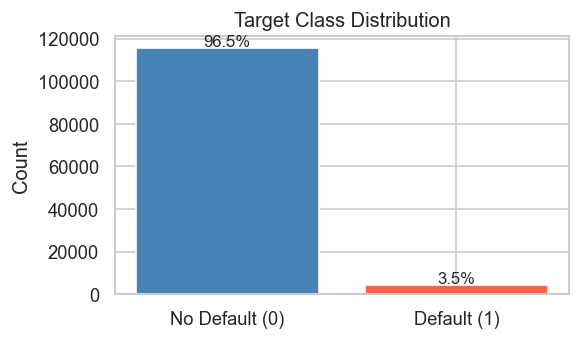

Default rate: 3.5%


In [4]:
def plot_target_balance(df: pd.DataFrame, target: str = 'default_flag') -> None:
    """Bar chart of the target class distribution with counts and percentages."""
    counts = df[target].value_counts().sort_index()
    pcts   = counts / counts.sum() * 100

    fig, ax = plt.subplots(figsize=(5, 3))
    bars = ax.bar(['No Default (0)', 'Default (1)'], counts.values, color=['steelblue', 'tomato'])
    for bar, pct in zip(bars, pcts.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + counts.max() * 0.01,
                f'{pct:.1f}%', ha='center', fontsize=10)
    ax.set_title('Target Class Distribution')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()
    print(f'Default rate: {pcts.get(1, pcts.iloc[-1]):.1f}%')


plot_target_balance(df_raw)

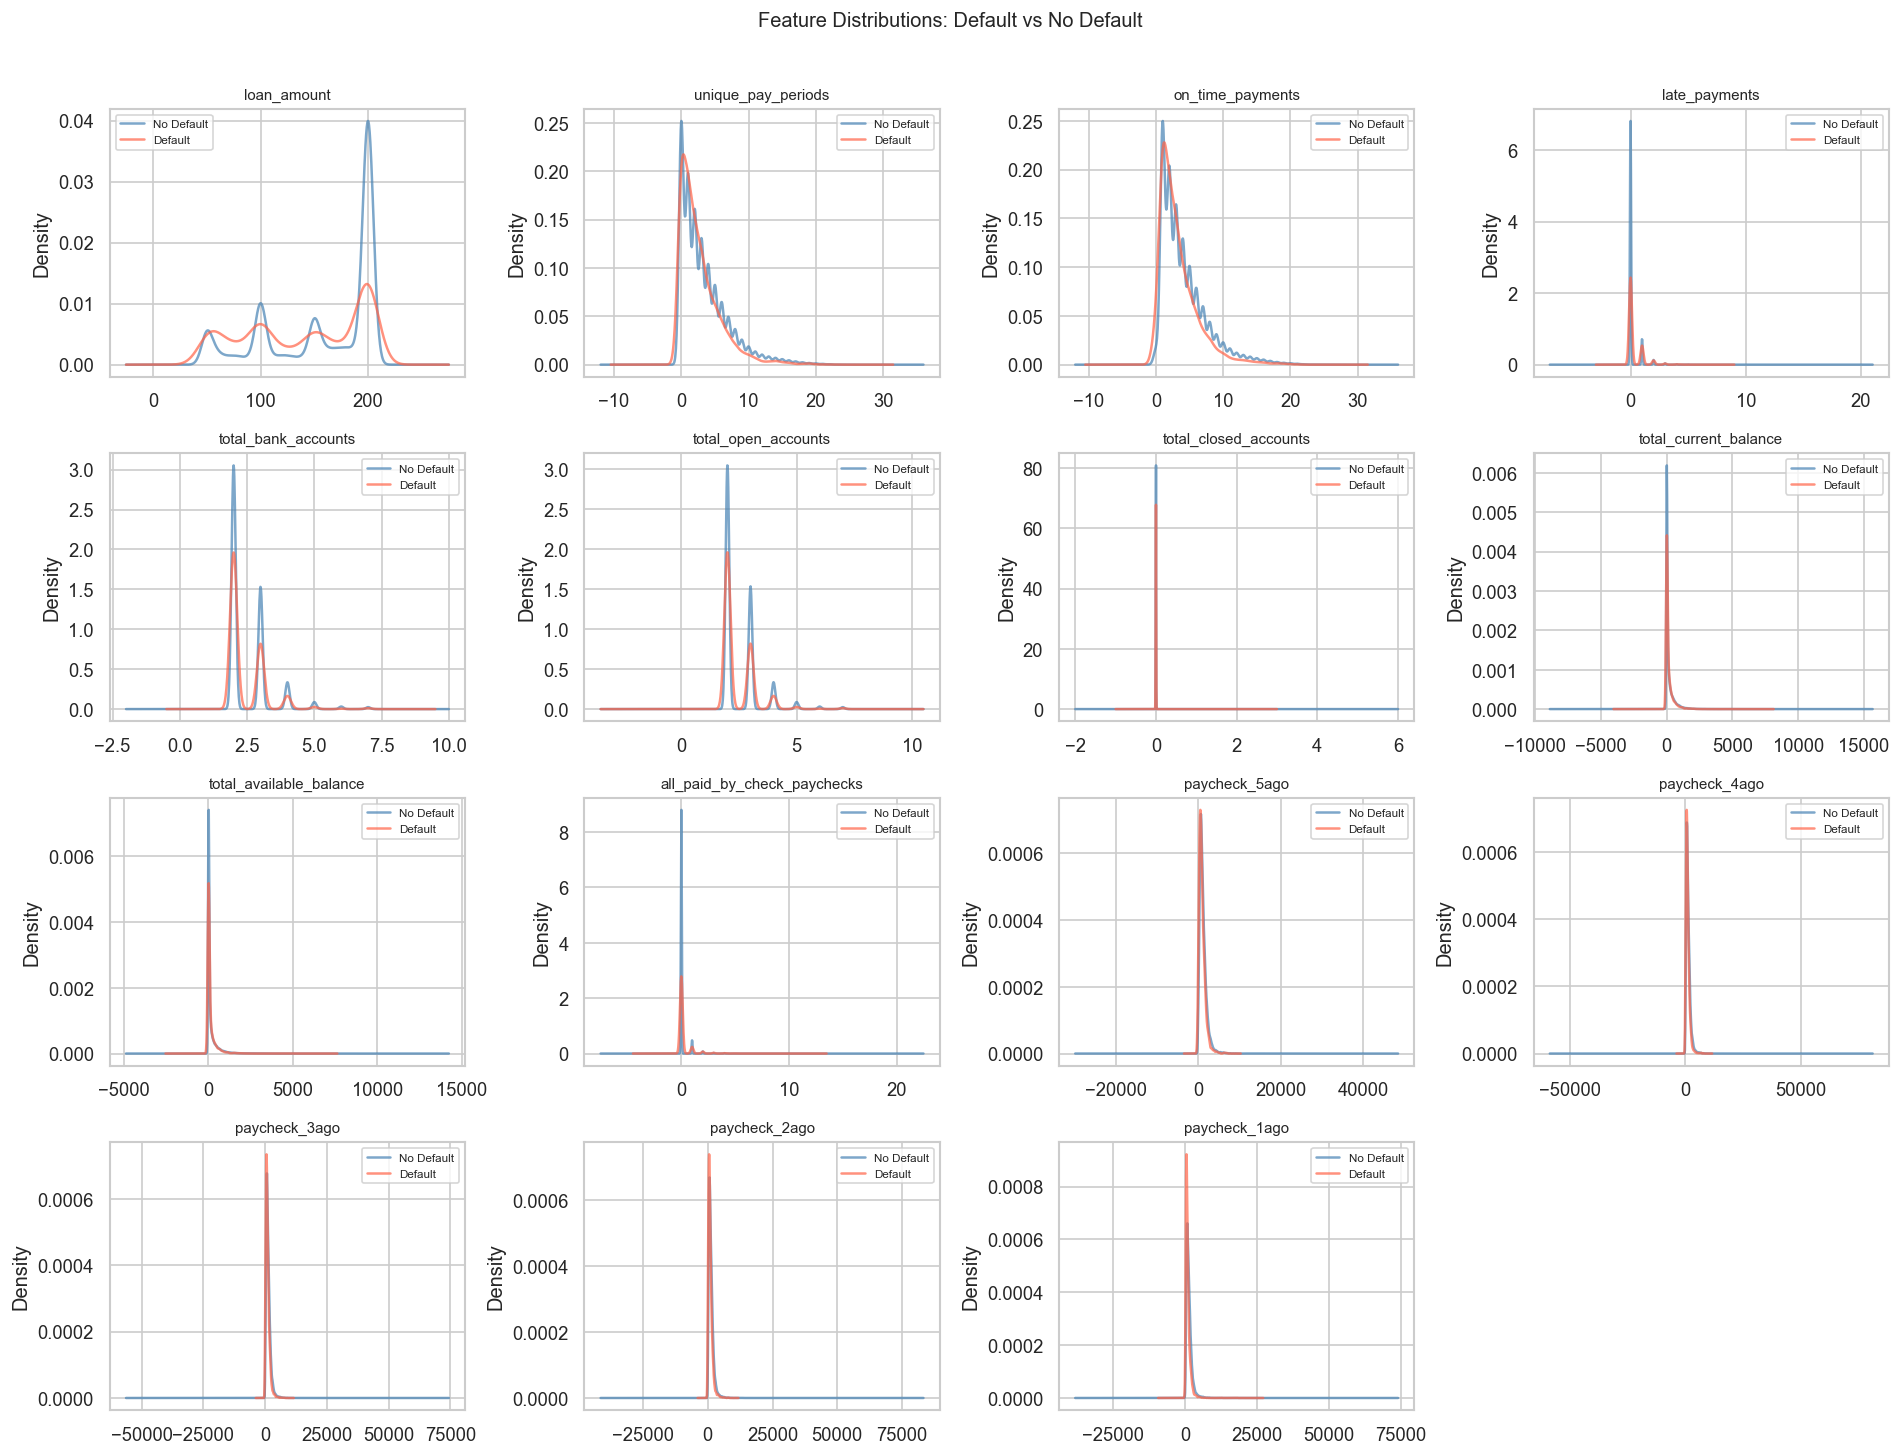

In [5]:
def plot_numeric_distributions(df: pd.DataFrame, target: str = 'default_flag',
                               cols: list = None, max_cols: int = 16) -> None:
    """
    For each numeric column, plot overlapping KDEs for defaulters vs non-defaulters.
    This reveals which raw features already discriminate between the two groups.
    """
    numeric_cols = df.select_dtypes(include='number').columns.drop(target, errors='ignore')
    if cols:
        numeric_cols = [c for c in cols if c in numeric_cols]
    numeric_cols = numeric_cols[:max_cols]

    ncols = 4
    nrows = (len(numeric_cols) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
    axes = axes.flatten()

    for ax, col in zip(axes, numeric_cols):
        for flag, label, color in [(0, 'No Default', 'steelblue'), (1, 'Default', 'tomato')]:
            subset = df.loc[df[target] == flag, col].dropna()
            subset.plot.kde(ax=ax, label=label, color=color, alpha=0.7)
        ax.set_title(col, fontsize=9)
        ax.set_xlabel('')
        ax.legend(fontsize=7)

    for ax in axes[len(numeric_cols):]:
        ax.set_visible(False)

    plt.suptitle('Feature Distributions: Default vs No Default', y=1.01, fontsize=12)
    plt.tight_layout()
    plt.show()


plot_numeric_distributions(df_raw)

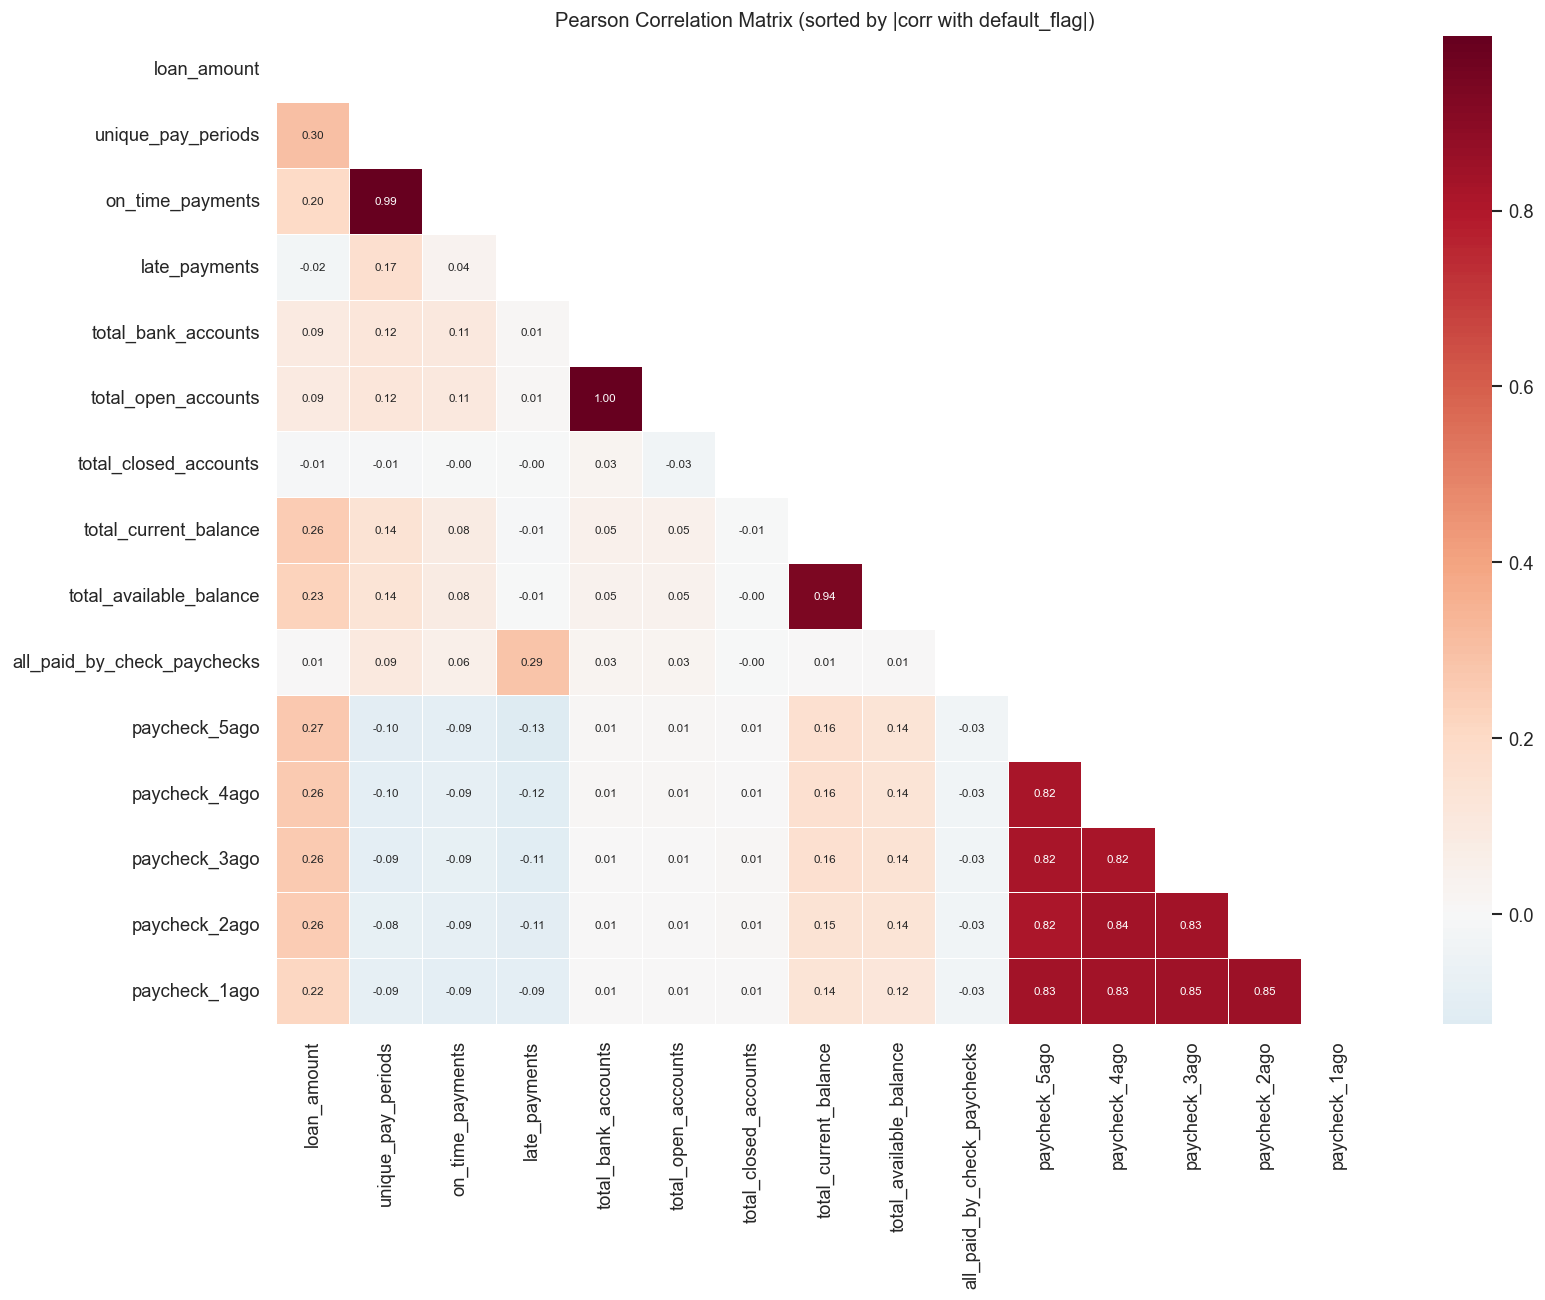

In [6]:
def plot_correlation_heatmap(df: pd.DataFrame, target: str = 'default_flag') -> None:
    """
    Correlation heatmap of numeric features, sorted by correlation with the target.
    """
    numeric_df = df.select_dtypes(include='number')
    corr = numeric_df.corr()

    # Sort columns/rows by absolute correlation with target
    if target in corr:
        order = corr[target].abs().sort_values(ascending=False).index
        corr = corr.loc[order, order]

    fig, ax = plt.subplots(figsize=(14, 11))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, linewidths=0.3, ax=ax, annot_kws={'size': 7})
    ax.set_title('Pearson Correlation Matrix (sorted by |corr with default_flag|)')
    plt.tight_layout()
    plt.show()


plot_correlation_heatmap(df_raw)

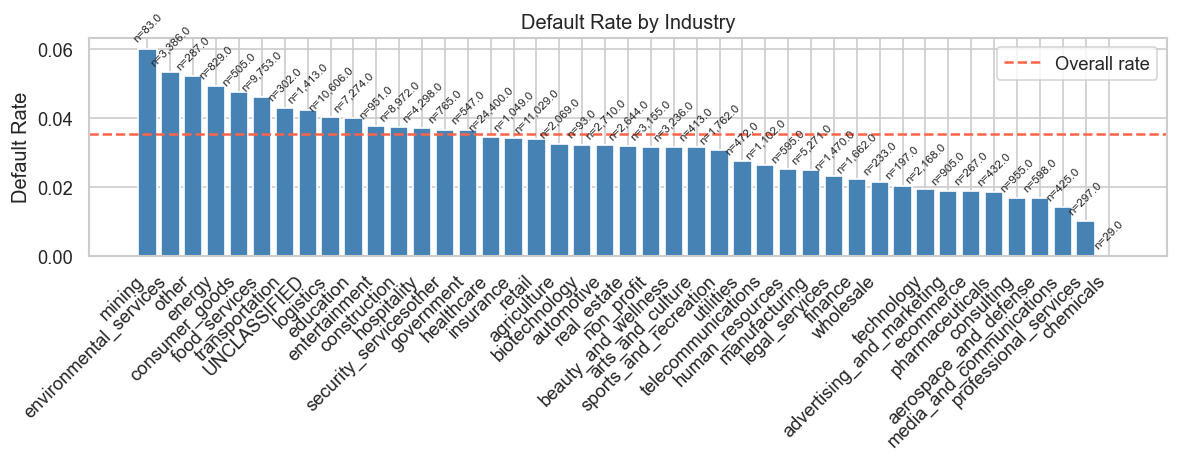

In [7]:
def plot_industry_default_rate(df: pd.DataFrame,
                               industry_col: str = 'industry_label',
                               target: str = 'default_flag') -> None:
    """
    Bar chart of default rate by industry, sorted descending.
    Helps identify high-risk sectors and informs how aggressively to use industry as a feature.
    """
    rates = (
        df.groupby(industry_col)[target]
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'default_rate', 'count': 'n'})
        .sort_values('default_rate', ascending=False)
    )

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.bar(rates.index, rates['default_rate'], color='steelblue')
    for bar, (_, row) in zip(bars, rates.iterrows()):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.002,
                f'n={row["n"]:,}', ha='center', fontsize=7, rotation=45)
    ax.axhline(df[target].mean(), color='tomato', linestyle='--', label='Overall rate')
    ax.set_title('Default Rate by Industry')
    ax.set_ylabel('Default Rate')
    ax.set_xticklabels(rates.index, rotation=45, ha='right')
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_industry_default_rate(df_raw)

## 3. Feature Engineering

We create domain-driven features that capture:
- **Creditworthiness**: repayment history rate, payment consistency
- **Income**: average paycheck, trend (growing vs shrinking), volatility
- **Debt load**: loan-to-income ratio
- **Stability**: tenure at employer, time as Clair member
- **Liquidity**: available vs total balance, account structure
- **Timing**: days since last paycheck (proxy for cash pressure)

In [8]:
def parse_dates(df: pd.DataFrame) -> pd.DataFrame:
    """
    Coerce all date-like columns to datetime, returning a copy.
    Silently handles columns that are already datetime or non-parseable.
    """
    date_cols = [
        'started_onboarding_at', 'hire_date', 'loan_creation_dt',
        'due_date', 'date_of_last_paycheck'
    ]
    df = df.copy()
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')
    return df


def compute_paycheck_stats(df: pd.DataFrame) -> pd.DataFrame:
    """
    Derive summary statistics from the five historical paycheck columns.
    Trend is estimated as the slope of a simple linear regression (paycheck number → amount),
    capturing whether income is rising, flat, or falling.
    """
    paycheck_cols = [f'paycheck_{i}ago' for i in range(5, 0, -1)]
    present = [c for c in paycheck_cols if c in df.columns]
    if not present:
        return df

    paycheck_arr = df[present].values.astype(float)  # shape (n, k)
    k = paycheck_arr.shape[1]
    x = np.arange(k)  # [0, 1, 2, 3, 4] — most distant to most recent
    x_centered = x - x.mean()

    df = df.copy()
    df['avg_paycheck']         = np.nanmean(paycheck_arr, axis=1)
    df['paycheck_volatility']  = np.nanstd(paycheck_arr, axis=1)
    df['min_paycheck']         = np.nanmin(paycheck_arr, axis=1)

    # Slope via Σ(x*y) / Σ(x²), ignoring NaNs column-wise
    numerator   = np.nansum(paycheck_arr * x_centered, axis=1)
    denominator = np.nansum(~np.isnan(paycheck_arr) * x_centered**2, axis=1)
    df['paycheck_trend'] = np.where(denominator > 0, numerator / denominator, 0.0)

    return df


def compute_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute day-difference features that capture tenure, platform loyalty, and cash timing.
    All deltas are measured relative to loan_creation_dt (the moment of the advance request).
    """
    df = df.copy()
    ref = df['loan_creation_dt']

    df['days_since_hire']         = (ref - df['hire_date']).dt.days
    df['days_as_clair_member']    = (ref - df['started_onboarding_at']).dt.days
    df['days_since_last_paycheck']= (ref - df['date_of_last_paycheck']).dt.days
    df['loan_term_days']          = (df['due_date'] - ref).dt.days

    return df


def compute_ratio_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Derive ratio features that normalise absolute values into relative measures.
    Small epsilon prevents division-by-zero for edge cases.
    """
    df = df.copy()
    eps = 1e-6

    total_payments = df['on_time_payments'] + df['late_payments']
    df['on_time_rate']           = df['on_time_payments'] / (total_payments + eps)
    df['late_rate']              = df['late_payments']    / (total_payments + eps)

    df['loan_to_avg_paycheck']   = df['loan_amount'] / (df['avg_paycheck'] + eps)
    df['avail_balance_ratio']    = df['total_available_balance'] / (df['total_current_balance'] + eps)
    df['open_account_ratio']     = df['total_open_accounts'] / (df['total_bank_accounts'] + eps)

    # Pay periods per month (rough cadence proxy)
    df['pay_periods_per_month']  = df['unique_pay_periods'] / ((df['days_as_clair_member'] + eps) / 30)

    return df


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Master feature engineering pipeline. Applies all sub-routines in order.
    Returns a new DataFrame with original columns plus all engineered features.
    """
    df = parse_dates(df)
    df = compute_paycheck_stats(df)
    df = compute_temporal_features(df)
    df = compute_ratio_features(df)
    return df


df = engineer_features(df_raw)
print(f'Shape after feature engineering: {df.shape}')
print('New columns:', [c for c in df.columns if c not in df_raw.columns])

Shape after feature engineering: (119609, 38)
New columns: ['avg_paycheck', 'paycheck_volatility', 'min_paycheck', 'paycheck_trend', 'days_since_hire', 'days_as_clair_member', 'days_since_last_paycheck', 'loan_term_days', 'on_time_rate', 'late_rate', 'loan_to_avg_paycheck', 'avail_balance_ratio', 'open_account_ratio', 'pay_periods_per_month']


## 4. Preprocessing Pipeline

In [9]:
# Columns to drop: IDs, raw dates (already captured as day-differences), raw paycheck columns
DROP_COLS = [
    'user_id', 'business_id',
    'started_onboarding_at', 'hire_date', 'loan_creation_dt', 'due_date', 'date_of_last_paycheck',
    'paycheck_5ago', 'paycheck_4ago', 'paycheck_3ago', 'paycheck_2ago', 'paycheck_1ago',
]

CATEGORICAL_COLS = ['industry_label', 'all_paid_by_check_paychecks']


def prepare_xy(df: pd.DataFrame,
               target: str = 'default_flag',
               drop_cols: list = DROP_COLS,
               cat_cols: list = CATEGORICAL_COLS) -> tuple:
    """
    Split the DataFrame into X (features) and y (target).
    Drops identifier/raw-date columns that are not predictive after engineering.
    Returns X (DataFrame) and y (Series).
    """
    cols_to_drop = [c for c in drop_cols if c in df.columns] + [target]
    X = df.drop(columns=cols_to_drop)
    y = df[target].astype(int)
    return X, y


def build_preprocessor(X: pd.DataFrame,
                       cat_cols: list = CATEGORICAL_COLS) -> ColumnTransformer:
    """
    Build a sklearn ColumnTransformer that:
    - Imputes and scales numeric features (median imputation + StandardScaler)
    - Imputes and one-hot-encodes categorical features

    Median imputation is chosen over mean because paycheck/balance columns
    tend to be right-skewed and may have a small number of extreme outliers.
    """
    cat_present  = [c for c in cat_cols if c in X.columns]
    num_cols     = [c for c in X.columns if c not in cat_present]

    numeric_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ])

    categorical_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_pipe,     num_cols),
            ('cat', categorical_pipe, cat_present),
        ],
        remainder='drop'
    )
    return preprocessor


X, y = prepare_xy(df)
print(f'Feature matrix shape: {X.shape}')
print(f'Positive class (defaults): {y.sum():,} / {len(y):,} ({y.mean()*100:.1f}%)')

Feature matrix shape: (119609, 25)
Positive class (defaults): 4,223 / 119,609 (3.5%)


## 5. Model Training

In [10]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def train_logistic_regression(X: pd.DataFrame, y: pd.Series) -> tuple:
    """
    Fit a Logistic Regression baseline with cross-validated probability predictions.
    Uses class_weight='balanced' to handle potential class imbalance without resampling,
    keeping the pipeline simpler and the probability calibration intact.
    Returns (pipeline, oof_proba) where oof_proba are out-of-fold predicted probabilities.
    """
    preprocessor = build_preprocessor(X)
    pipeline = Pipeline([
        ('prep', preprocessor),
        ('clf',  LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=RANDOM_STATE,
        ))
    ])
    oof_proba = cross_val_predict(pipeline, X, y, cv=CV, method='predict_proba')[:, 1]
    pipeline.fit(X, y)  # Refit on full data for final model
    return pipeline, oof_proba


def train_lightgbm(X: pd.DataFrame, y: pd.Series) -> tuple:
    """
    Fit a LightGBM gradient-boosted classifier.
    Key design choices:
    - class_weight='balanced': compensates for class imbalance without oversampling
    - num_leaves=31, min_child_samples=50: prevents overfitting on small datasets
    - OOF predictions: honest evaluation that avoids train-set leakage
    LightGBM handles missing values natively, so no imputation is needed.
    Returns (model, oof_proba, feature_names).
    """
    cat_present   = [c for c in CATEGORICAL_COLS if c in X.columns]
    X_lgb         = X.copy()
    for col in cat_present:
        X_lgb[col] = X_lgb[col].astype('category')

    scale_pos_weight = (y == 0).sum() / (y == 1).sum()

    model_params = dict(
        objective        = 'binary',
        metric           = 'auc',
        num_leaves       = 31,
        learning_rate    = 0.05,
        n_estimators     = 400,
        min_child_samples= 50,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        scale_pos_weight = scale_pos_weight,
        random_state     = RANDOM_STATE,
        verbose          = -1,
    )

    oof_proba = np.zeros(len(y))
    for fold, (train_idx, val_idx) in enumerate(CV.split(X_lgb, y)):
        model = lgb.LGBMClassifier(**model_params)
        model.fit(
            X_lgb.iloc[train_idx], y.iloc[train_idx],
            eval_set=[(X_lgb.iloc[val_idx], y.iloc[val_idx])],
            callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
        )
        oof_proba[val_idx] = model.predict_proba(X_lgb.iloc[val_idx])[:, 1]

    # Refit on full data for inference
    final_model = lgb.LGBMClassifier(**model_params)
    final_model.fit(X_lgb, y)

    return final_model, oof_proba, list(X_lgb.columns)


print('Training Logistic Regression baseline...')
lr_pipeline, lr_oof = train_logistic_regression(X, y)

print('Training LightGBM...')
lgbm_model, lgbm_oof, feature_names = train_lightgbm(X, y)

print('Training complete.')

Training Logistic Regression baseline...
Training LightGBM...
Training complete.


## 6. Evaluation

--- Out-of-fold metrics ---
Logistic Regression             ROC AUC=0.7169   PR AUC=0.0942
LightGBM                        ROC AUC=0.7438   PR AUC=0.1231


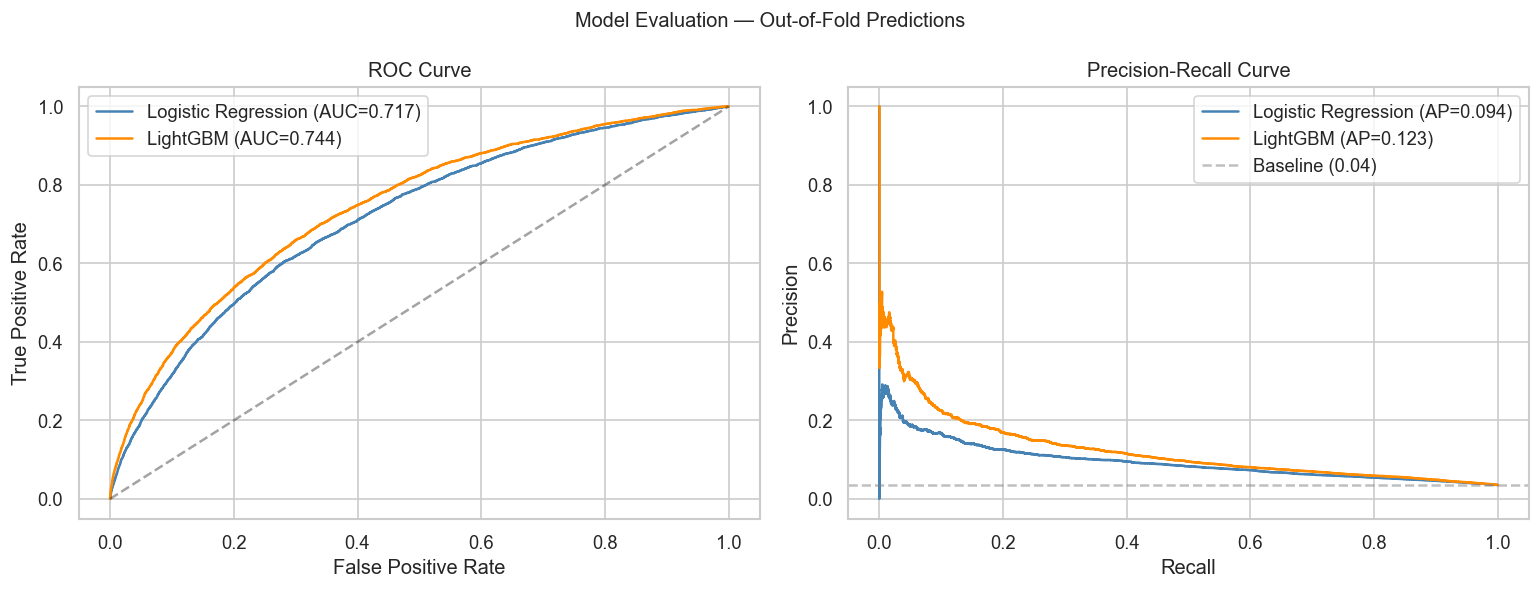

In [11]:
def evaluate_model(y_true: pd.Series, y_prob: np.ndarray, model_name: str = '') -> dict:
    """
    Compute ROC AUC and PR AUC. ROC AUC measures overall discrimination;
    PR AUC is more informative under class imbalance because it focuses on the
    minority (default) class rather than treating both classes symmetrically.
    """
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc  = average_precision_score(y_true, y_prob)
    print(f'{model_name:30s}  ROC AUC={roc_auc:.4f}   PR AUC={pr_auc:.4f}')
    return {'roc_auc': roc_auc, 'pr_auc': pr_auc}


def plot_roc_pr_curves(y_true: pd.Series,
                       predictions: dict) -> None:
    """
    Plot ROC and Precision-Recall curves for one or more models on a shared figure.
    `predictions` is a dict of {model_name: y_prob_array}.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    colors = ['steelblue', 'darkorange', 'green']

    for (name, y_prob), color in zip(predictions.items(), colors):
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        pr, rc, _   = precision_recall_curve(y_true, y_prob)
        roc_auc     = roc_auc_score(y_true, y_prob)
        pr_auc      = average_precision_score(y_true, y_prob)

        ax1.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})', color=color)
        ax2.plot(rc,  pr,  label=f'{name} (AP={pr_auc:.3f})',   color=color)

    ax1.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax1.set_xlabel('False Positive Rate');
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('ROC Curve');  ax1.legend()

    baseline_pr = y_true.mean()
    ax2.axhline(baseline_pr, linestyle='--', color='grey', alpha=0.5, label=f'Baseline ({baseline_pr:.2f})')
    ax2.set_xlabel('Recall');  ax2.set_ylabel('Precision')
    ax2.set_title('Precision-Recall Curve');  ax2.legend()

    plt.suptitle('Model Evaluation — Out-of-Fold Predictions', fontsize=12)
    plt.tight_layout()
    plt.show()


print('--- Out-of-fold metrics ---')
lr_metrics   = evaluate_model(y, lr_oof,   model_name='Logistic Regression')
lgbm_metrics = evaluate_model(y, lgbm_oof, model_name='LightGBM')

plot_roc_pr_curves(y, {'Logistic Regression': lr_oof, 'LightGBM': lgbm_oof})

## 7. Business Threshold Selection

A model produces probabilities; the **threshold** converts probabilities into decisions (approve / reject). The optimal threshold depends on the cost structure:

| Decision | Outcome | Cost |
|---|---|---|
| Approve → Default  | False Negative | High (full loan loss) |
| Reject  → No Default | False Positive | Moderate (lost fee revenue) |
| Approve → No Default | True Positive  | 0 (good outcome) |
| Reject  → Default  | True Negative  | 0 (avoided loss) |

We parameterise: **cost_fn = cost of missing a default / cost of rejecting a good user**.
A ratio of 5 means one default is as bad as rejecting 5 good users.

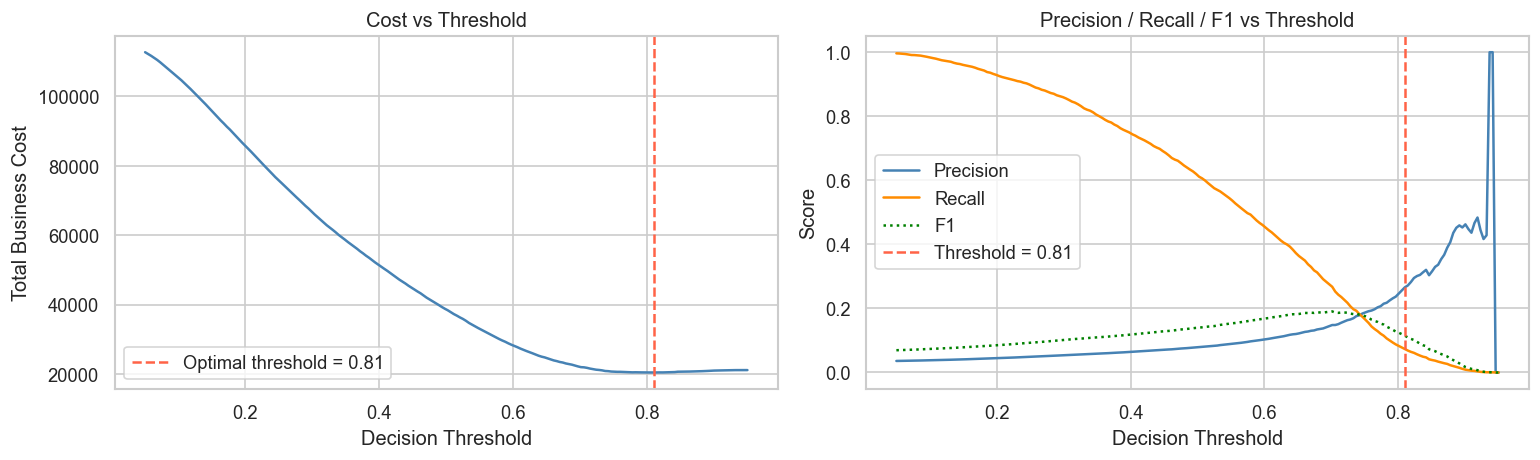

Optimal threshold: 0.81
  Precision: 0.266
  Recall:    0.073
  F1:        0.115


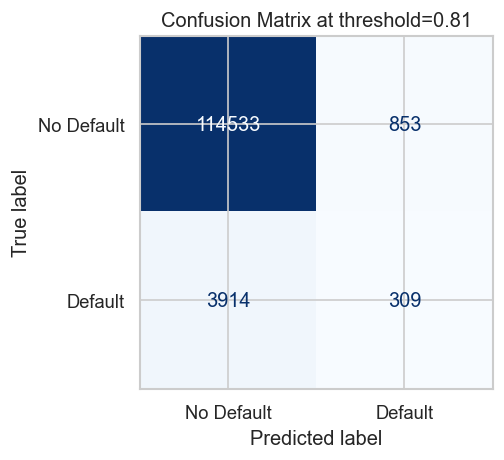

In [12]:
def compute_threshold_costs(y_true: pd.Series, y_prob: np.ndarray,
                             cost_fn: float = 5.0,
                             cost_fp: float = 1.0) -> pd.DataFrame:
    """
    For each decision threshold, compute the normalised total business cost:
        total_cost = cost_fn * FN_count + cost_fp * FP_count
    Also returns precision, recall, and F1 at each threshold.

    Args:
        cost_fn: relative cost of a missed default (false negative)
        cost_fp: relative cost of a rejected good user (false positive)
    """
    thresholds = np.linspace(0.05, 0.95, 200)
    records = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        precision = tp / (tp + fp + 1e-9)
        recall    = tp / (tp + fn + 1e-9)
        f1        = 2 * precision * recall / (precision + recall + 1e-9)
        total_cost= cost_fn * fn + cost_fp * fp
        records.append({'threshold': t, 'precision': precision, 'recall': recall,
                        'f1': f1, 'total_cost': total_cost, 'fp': fp, 'fn': fn})
    return pd.DataFrame(records)


def plot_threshold_analysis(cost_df: pd.DataFrame,
                             best_threshold: float) -> None:
    """Plot business cost and precision/recall vs decision threshold."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.plot(cost_df['threshold'], cost_df['total_cost'], color='steelblue')
    ax1.axvline(best_threshold, color='tomato', linestyle='--',
                label=f'Optimal threshold = {best_threshold:.2f}')
    ax1.set_xlabel('Decision Threshold');  ax1.set_ylabel('Total Business Cost')
    ax1.set_title('Cost vs Threshold');  ax1.legend()

    ax2.plot(cost_df['threshold'], cost_df['precision'], label='Precision', color='steelblue')
    ax2.plot(cost_df['threshold'], cost_df['recall'],    label='Recall',    color='darkorange')
    ax2.plot(cost_df['threshold'], cost_df['f1'],        label='F1',        color='green', linestyle=':')
    ax2.axvline(best_threshold, color='tomato', linestyle='--',
                label=f'Threshold = {best_threshold:.2f}')
    ax2.set_xlabel('Decision Threshold');  ax2.set_ylabel('Score')
    ax2.set_title('Precision / Recall / F1 vs Threshold');  ax2.legend()

    plt.tight_layout()
    plt.show()


def select_threshold(y_true: pd.Series, y_prob: np.ndarray,
                      cost_fn: float = 5.0, cost_fp: float = 1.0) -> float:
    """
    Find and report the threshold that minimises total weighted business cost.
    Prints key metrics at the chosen threshold.
    """
    cost_df   = compute_threshold_costs(y_true, y_prob, cost_fn, cost_fp)
    best_row  = cost_df.loc[cost_df['total_cost'].idxmin()]
    best_t    = best_row['threshold']

    plot_threshold_analysis(cost_df, best_t)

    print(f'Optimal threshold: {best_t:.2f}')
    print(f'  Precision: {best_row["precision"]:.3f}')
    print(f'  Recall:    {best_row["recall"]:.3f}')
    print(f'  F1:        {best_row["f1"]:.3f}')

    # Confusion matrix at chosen threshold
    y_pred = (y_prob >= best_t).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Default', 'Default'])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix at threshold={best_t:.2f}')
    plt.tight_layout()
    plt.show()

    return best_t


# Use LightGBM (better model) for threshold selection
# Assume a missed default costs 5× more than rejecting a good user
COST_FN = 5.0
COST_FP = 1.0

best_threshold = select_threshold(y, lgbm_oof, cost_fn=COST_FN, cost_fp=COST_FP)

## 8. Feature Importance

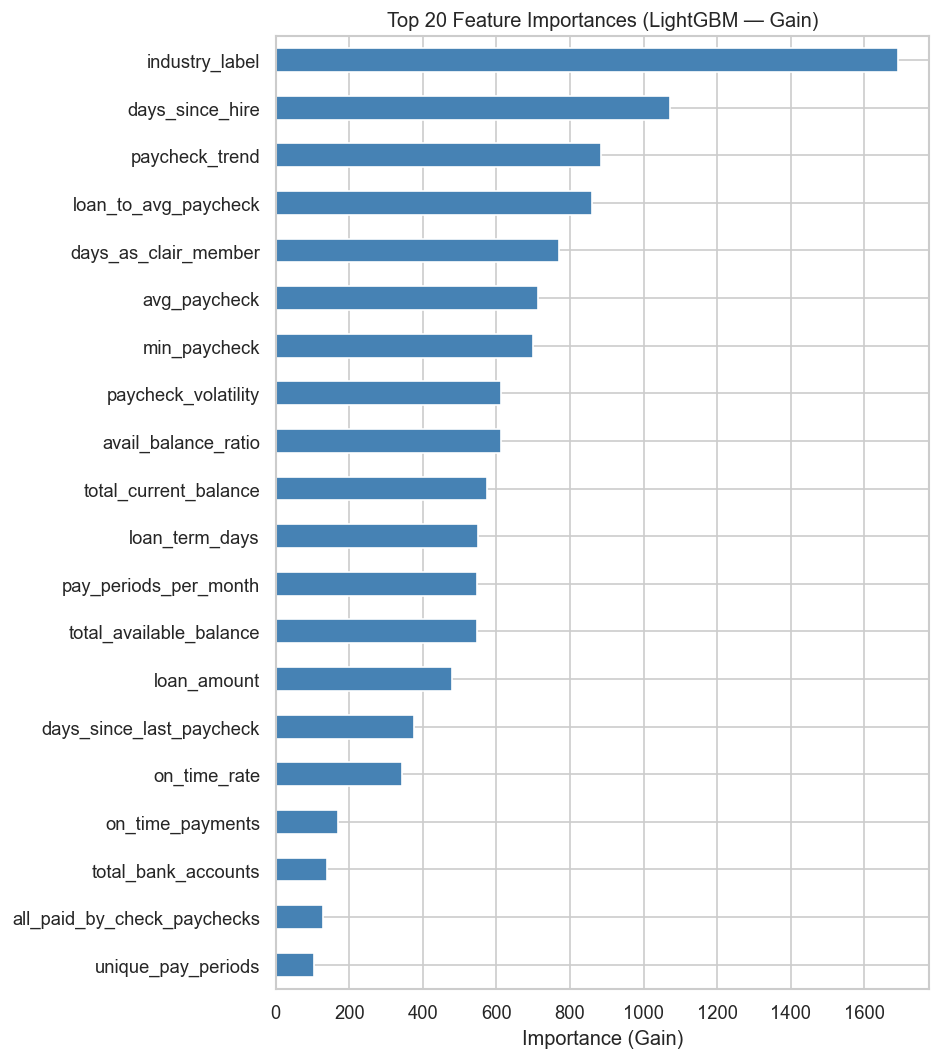

In [13]:
def plot_feature_importance(model: lgb.LGBMClassifier,
                             feature_names: list,
                             top_n: int = 20) -> None:
    """
    Horizontal bar chart of the top-N LightGBM feature importances (gain).
    'gain' is more informative than 'split' because it measures total information
    gained from each feature across all trees.
    """
    importances = pd.Series(
        model.feature_importances_,
        index=feature_names
    ).sort_values(ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(8, top_n * 0.4 + 1))
    importances[::-1].plot.barh(ax=ax, color='steelblue')
    ax.set_title(f'Top {top_n} Feature Importances (LightGBM — Gain)')
    ax.set_xlabel('Importance (Gain)')
    plt.tight_layout()
    plt.show()


plot_feature_importance(lgbm_model, feature_names)

## 9. Bonus — Safe Advance Amount Estimation

**Goal:** For approved users, estimate how much we can safely advance.

**Approach:** A simple, interpretable formula using outputs already available from the risk model:

$$
\text{safe\_amount} = \text{requested\_amount} \times (1 - P(\text{default})) \times \text{liquidity\_factor}
$$

where:
$$
\text{liquidity\_factor} = \min\left(1,\ \frac{\text{available\_balance}}{\text{avg\_paycheck}}\right)
$$

**Intuition:**
- Higher default probability → lower fraction of the requested amount approved.
- Low available balance relative to paycheck → user is already cash-constrained → reduce offer further.
- A user with P(default)=0.05 and healthy liquidity gets ≈95% of what they asked for.
- A user with P(default)=0.40 gets at most 60%, and potentially less if liquidity is low.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Users approved (safe_amount > 0): 118,447 / 119,609
Mean safe amount (approved): $43.43
Mean requested amount:       $157.92


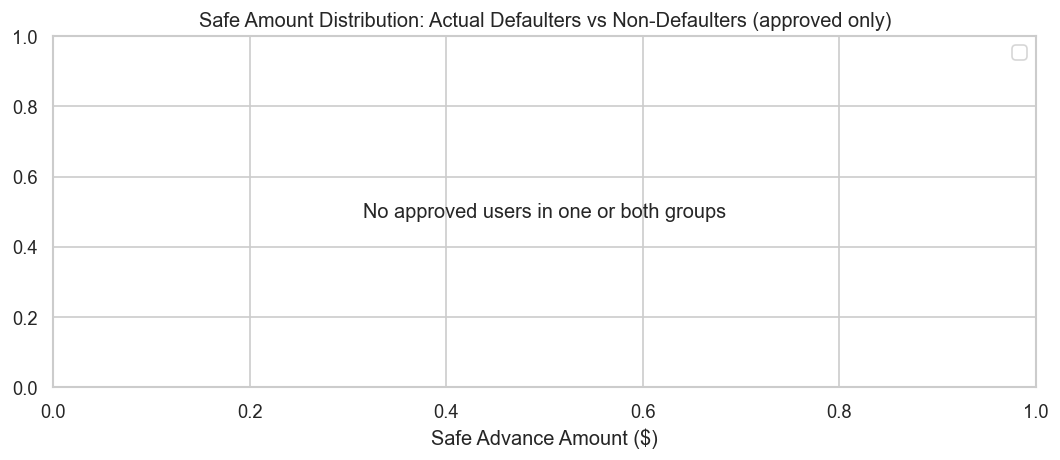

Mean safe amount by outcome (approved users only):
Series([], Name: safe_amount, dtype: float64)


In [14]:
def compute_liquidity_factor(df: pd.DataFrame,
                              avail_col: str = 'total_available_balance',
                              paycheck_col: str = 'avg_paycheck') -> np.ndarray:
    """
    Liquidity factor ∈ (0, 1]: ratio of available balance to average paycheck,
    capped at 1 so a user with more cash than their paycheck gets the full factor.
    NaN available balance is treated conservatively as 0 (unknown = cautious).
    """
    avail   = df[avail_col].fillna(0).clip(lower=0)
    avg_pay = df[paycheck_col].fillna(df[paycheck_col].median()).clip(lower=1)
    return np.minimum(avail / avg_pay, 1.0).values


def estimate_safe_amount(df: pd.DataFrame,
                          default_proba: np.ndarray,
                          requested_col: str = 'loan_amount',
                          min_approval_fraction: float = 0.25) -> pd.Series:
    """
    Estimate the maximum safe advance amount for each observation.
    Users above the decision threshold (predicted to default) get $0.
    Approved users receive: requested_amount × (1 - P(default)) × liquidity_factor,
    with a floor of min_approval_fraction × requested_amount to avoid sending $0.01 offers.

    Args:
        min_approval_fraction: Minimum fraction of requested amount to offer approved users.
    """
    liquidity    = compute_liquidity_factor(df)
    confidence   = 1.0 - default_proba           # P(repayment)
    raw_fraction = confidence * liquidity
    # Clamp: approved users get at least min_approval_fraction of their request
    fraction     = np.maximum(raw_fraction, min_approval_fraction)
    safe_amounts = (df[requested_col].values * fraction).round(2)
    safe_amounts = pd.Series(safe_amounts, index=df.index)

    # Set to 0 for users predicted to default (above threshold)
    rejected     = default_proba >= best_threshold
    safe_amounts = safe_amounts.where(~rejected, other=0.0)

    return safe_amounts


def plot_safe_amount_distribution(df: pd.DataFrame,
                                   safe_amounts: pd.Series,
                                   target: str = 'default_flag') -> None:
    """
    Compare the distribution of safe amounts for actual defaulters vs non-defaulters.
    A well-calibrated model should offer lower amounts to eventual defaulters.
    Skips KDE if a group has no approved users (all rejected).
    """
    plot_df = pd.DataFrame({
        'safe_amount': safe_amounts,
        'actual': df[target].map({0: 'No Default', 1: 'Default'})
    }).query('safe_amount > 0')

    fig, ax = plt.subplots(figsize=(9, 4))
    plotted = False
    for label, color in [('No Default', 'steelblue'), ('Default', 'tomato')]:
        subset = plot_df.loc[plot_df['actual'] == label, 'safe_amount']
        if len(subset) > 1:
            subset.plot.kde(ax=ax, label=f'{label} (n={len(subset):,})', color=color, alpha=0.7)
            plotted = True
    if not plotted:
        ax.text(0.5, 0.5, 'No approved users in one or both groups',
                ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Safe Amount Distribution: Actual Defaulters vs Non-Defaulters (approved only)')
    ax.set_xlabel('Safe Advance Amount ($)')
    ax.legend()
    plt.tight_layout()
    plt.show()

    if not plot_df.empty:
        print('Mean safe amount by outcome (approved users only):')
        print(plot_df.groupby('actual')['safe_amount'].mean().round(2))


safe_amounts = estimate_safe_amount(df, lgbm_oof)

print(f'Users approved (safe_amount > 0): {(safe_amounts > 0).sum():,} / {len(safe_amounts):,}')
print(f'Mean safe amount (approved): ${safe_amounts[safe_amounts > 0].mean():.2f}')
print(f'Mean requested amount:       ${df["loan_amount"].mean():.2f}')

plot_safe_amount_distribution(df, safe_amounts)

## 10. Summary & Decision Rule

**Model:** LightGBM binary classifier, trained with 5-fold stratified cross-validation.

**Decision rule:**
> **Reject** the advance request if the model's estimated default probability ≥ `best_threshold`.

**Top predictors** (from feature importance analysis):
- Payment history rate (`on_time_rate`, `late_rate`)
- Income indicators (`avg_paycheck`, `paycheck_trend`)
- Debt load (`loan_to_avg_paycheck`)
- Tenure signals (`days_since_hire`, `days_as_clair_member`)

**Bonus — Safe Amount Formula:**
$$\text{safe\_amount} = \text{requested} \times (1 - P(\text{default})) \times \min\!\left(1,\, \frac{\text{available\_balance}}{\text{avg\_paycheck}}\right)$$

In [15]:
print('=== FINAL MODEL METRICS (Out-of-Fold) ===')
print(f'Logistic Regression   ROC AUC: {lr_metrics["roc_auc"]:.4f}   PR AUC: {lr_metrics["pr_auc"]:.4f}')
print(f'LightGBM              ROC AUC: {lgbm_metrics["roc_auc"]:.4f}   PR AUC: {lgbm_metrics["pr_auc"]:.4f}')
print(f'\nSelected decision threshold: {best_threshold:.2f}  (cost_fn={COST_FN}, cost_fp={COST_FP})')
print(f'Reject advances with P(default) >= {best_threshold:.2f}')

=== FINAL MODEL METRICS (Out-of-Fold) ===
Logistic Regression   ROC AUC: 0.7169   PR AUC: 0.0942
LightGBM              ROC AUC: 0.7438   PR AUC: 0.1231

Selected decision threshold: 0.81  (cost_fn=5.0, cost_fp=1.0)
Reject advances with P(default) >= 0.81
